##### Authors: Dovydas Venclovas, Ignas Jasinskis, Radin Azadmanesh
**Note to the reader:** the whole notebook takes around 30 minutes to run. We sincerely recommend to start running it in advance and come back after a good while.

### **Imports**

In [11]:
# from utils import visualise_gridsearch, fetch_top_predictions, make_top_3

import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline as SkPipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier, XGBRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import precision_score, accuracy_score

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

### **Utility functions**

Helper functions designed to make the following pipeline somewhat more concise. Moved to this notebook for convenience.

In [12]:
def make_top_3(model, X_test_sets, y_test_sets, regression=False):
    top3_list = []

    for i, X_test in enumerate(X_test_sets):
        if regression:
            preds = model.predict(X_test)
            
        else:
            preds = model.predict_proba(X_test)[:, 1]

        true_vals = y_test_sets[i]
        order = np.argsort(preds)[::-1][:3]

        top3_df = pd.DataFrame({
            "true_label": true_vals.iloc[order].values,
            "score": preds[order]
        })
        top3_list.append(top3_df)

    return top3_list


def fetch_top_predictions(top3_list, X_test_sets, y_test_sets, y_raw_test_sets):
    hit_list = []
    for i, (top3_df, _, _, _) in enumerate(
        zip(top3_list, X_test_sets, y_test_sets, y_raw_test_sets), 1
    ):
        hits = top3_df["true_label"].sum()
        hit_list.append(hits)

    return hit_list


def visualise_gridsearch(cv_results_df, param_x, param_y, param_split):
    for val in sorted(cv_results_df[param_split].unique()):
        subset = cv_results_df[cv_results_df[param_split] == val]

        pivot_table = subset.pivot_table(
            values="mean_test_score",
            index=param_x,
            columns=param_y
        )

        plt.figure(figsize=(6,4))
        sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="vlag")
        plt.title(f"Mean CV Score ({param_split}={val})")
        plt.ylabel(param_x)
        plt.xlabel(param_y)
        plt.show()

### **Data setup**

In [13]:
df = pd.read_csv('data/OnlineNewsPopularity.csv')
df = df.rename(columns=lambda x: x.strip())
y_raw = df['shares']

POPULARITY_SPLIT = 0.9

high_thresh = y_raw.quantile(POPULARITY_SPLIT)
y_class = (y_raw >= high_thresh).astype(int)

print("Class distribution:")
print(y_class.value_counts())

df_sorted = df.copy().sort_values('timedelta', ascending=False)

TRAIN_SPLIT = 0.85
train_size = int(len(df_sorted) * TRAIN_SPLIT)

train_df = df_sorted.iloc[:train_size]
test_df = df_sorted.iloc[train_size:]

X_train = train_df.drop(columns=['url', 'timedelta', 'shares'])
y_train_class = (train_df['shares'] >= high_thresh).astype(int)
y_train_reg_log = np.log1p(train_df['shares'])

X_test_full = test_df.drop(columns=['url', 'timedelta', 'shares'])
y_test_full_class = (test_df['shares'] >= high_thresh).astype(int)
y_test_full_reg_log = np.log1p(test_df['shares'])

test_splits = np.array_split(test_df, 100)

X_test_sets = []
y_test_sets_class = []
y_test_sets_reg_log = []

for ts in test_splits:
    X_test_sets.append(ts.drop(columns=['url', 'timedelta', 'shares']))
    y_test_sets_class.append((ts['shares'] >= high_thresh).astype(int))
    y_test_sets_reg_log.append(np.log1p(ts['shares']))

Class distribution:
shares
0    35615
1     4029
Name: count, dtype: int64


Below is a brief visual which displays the effect of log-transforming the target variable (applicable only for regression models).

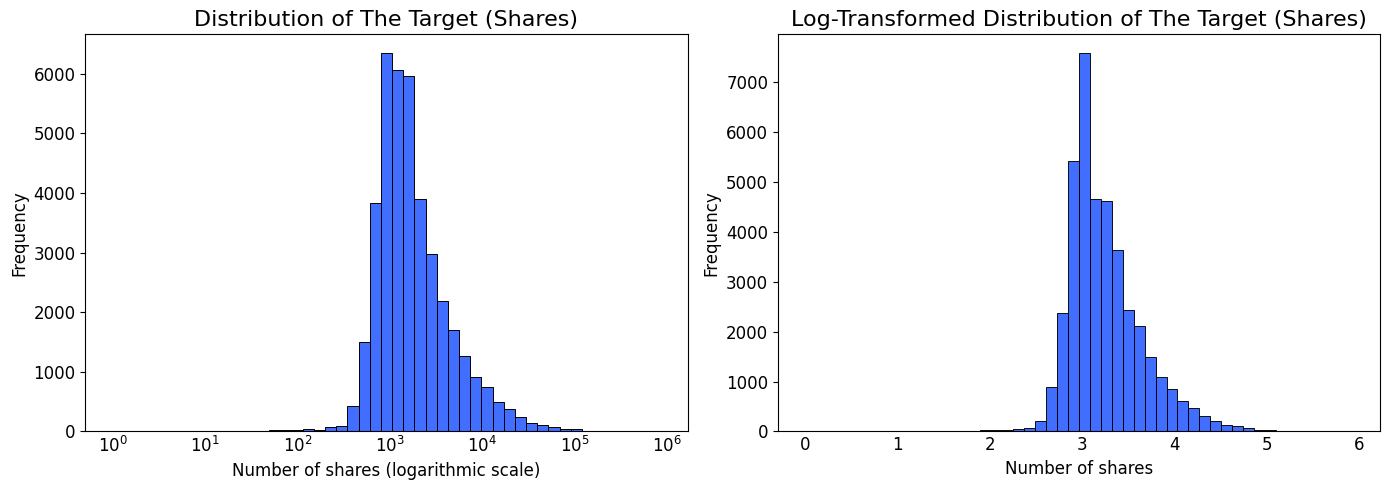

In [14]:
target = df['shares']
target_pos = target[target > 0]

bins = np.logspace(
    np.log10(target_pos.min()),
    np.log10(target_pos.max()),
    50
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bright_palette = sns.color_palette('bright')
blue = bright_palette[0]

sns.histplot(
    target_pos,
    bins=bins,
    edgecolor='black',
    linewidth=0.7,
    ax=axes[0],
    color=blue
)
axes[0].set_xscale('log')
axes[0].set_xlabel('Number of shares (logarithmic scale)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of The Target (Shares)', fontsize=16)

sns.histplot(
    np.log10(target_pos),
    bins=50,
    ax=axes[1],
    color=blue
)
axes[1].set_xlabel('Number of shares', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Log-Transformed Distribution of The Target (Shares)', fontsize=16)

for ax in axes:
    ax.tick_params(axis='x', which='both', length=0, labelsize=12)
    ax.tick_params(axis='y', which='both', labelsize=12)


plt.tight_layout()
plt.show()

Time series split to try imitating our business objective somewhat more accurately.

In [15]:
cv = TimeSeriesSplit(n_splits=3)

Two dictionaries that will collect all CV and Test scores from the models. We will use them in the 'Model comparison' section.

In [73]:
cv_collector = {'xgb': {'baseline': 0, 'undersampling': 0, 'smote': 0, 'regression': 0},
                'rf': {'baseline': 0, 'undersampling': 0, 'smote': 0, 'regression': 0},
                'cat': {'baseline': 0, 'undersampling': 0, 'smote': 0, 'regression': 0}}

score_collector = {'xgb': {'baseline': 0, 'undersampling': 0, 'smote': 0, 'regression': 0},
                'rf': {'baseline': 0, 'undersampling': 0, 'smote': 0, 'regression': 0},
                'cat': {'baseline': 0, 'undersampling': 0, 'smote': 0, 'regression': 0}}

at_least_one_collector = {'xgb': {'baseline': 0, 'undersampling': 0, 'smote': 0, 'regression': 0},
                'rf': {'baseline': 0, 'undersampling': 0, 'smote': 0, 'regression': 0},
                'cat': {'baseline': 0, 'undersampling': 0, 'smote': 0, 'regression': 0}}



### **Scoring functions** 

The scoring function are supposed to customize the CV process to align it more with the overall business objective. 

In [17]:
def topk_scorer(estimator, X, y_true):
    proba = estimator.predict_proba(X)[:, 1]

    true_k = int(y_true.sum())

    top_idx = np.argsort(proba)[-true_k:]

    y_pred = np.zeros_like(y_true)
    y_pred[top_idx] = 1

    return precision_score(y_true, y_pred, zero_division=0)


In [18]:
def topk_regression_scorer(estimator, X, y_true, top_pct=0.1):
    y_pred = estimator.predict(X)
    k = int(len(y_true) * top_pct)

    top_pred_idx = np.argsort(y_pred)[-k:]
    top_true_idx = np.argsort(y_true)[-k:]

    y_pred_binary = np.zeros_like(y_true, dtype=int)
    y_true_binary = np.zeros_like(y_true, dtype=int)

    y_pred_binary[top_pred_idx] = 1
    y_true_binary[top_true_idx] = 1

    return precision_score(y_true_binary, y_pred_binary)

### **XGBoost baseline** 

In [19]:
standard_pipeline = SkPipeline([
    ("xgb", XGBClassifier(
        random_state=42,
    ))
])

standard_param_grid = {
    "xgb__n_estimators": [50, 100, 150],
    "xgb__learning_rate": [0.01, 0.05, 0.1],
    "xgb__max_depth": [5, 7, 9],
}

standard_grid = GridSearchCV(
    estimator=standard_pipeline,
    param_grid=standard_param_grid,
    scoring=topk_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

print("\n=== Running GridSearchCV ===")
standard_grid.fit(X_train, y_train_class)
print("\nBest parameters:", standard_grid.best_params_)
print("Best CV score:", round(standard_grid.best_score_, 3))
cv_collector['xgb']['baseline'] = round(standard_grid.best_score_, 4)


=== Running GridSearchCV ===
Fitting 3 folds for each of 27 candidates, totalling 81 fits

Best parameters: {'xgb__learning_rate': 0.05, 'xgb__max_depth': 5, 'xgb__n_estimators': 100}
Best CV score: 0.262


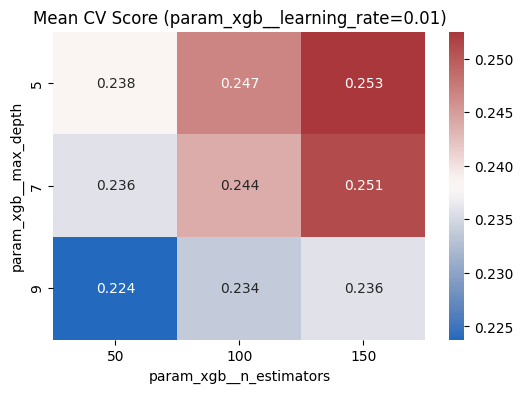

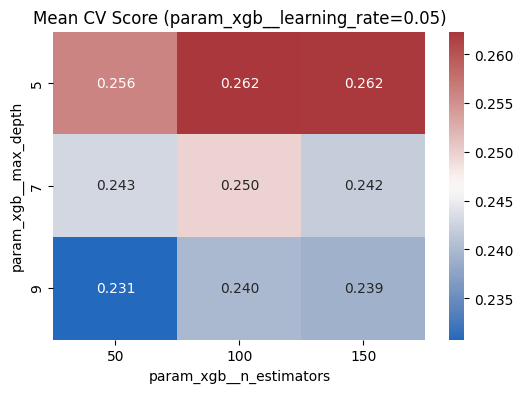

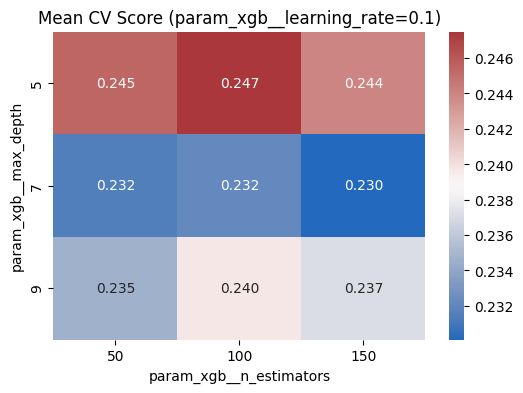

In [20]:
visualise_gridsearch(pd.DataFrame(standard_grid.cv_results_), 
                     'param_xgb__max_depth', 'param_xgb__n_estimators', 'param_xgb__learning_rate')

In [87]:
best_model = standard_grid.best_estimator_

top10_list = make_top_3(best_model, X_test_sets, y_test_sets_class)
hit_list = fetch_top_predictions(top10_list, X_test_sets, y_test_sets_class, y_test_sets_reg_log)

print(np.average(hit_list))
score_collector['xgb']['baseline'] = round(np.average(hit_list), 4)
at_least_one_collector['xgb']['baseline'] = sum([i>=1 for i in hit_list])/100

0.84


### **XGBoost with undersampling**

In [22]:
undersampling_pipeline = ImbPipeline([
    ('undersample', RandomUnderSampler(random_state=42)),
    ('xgb', XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

undersampling_param_grid = {
    "xgb__n_estimators": [100, 300, 500],
    "xgb__learning_rate": [0.01, 0.05, 0.1],
    "xgb__max_depth": [1, 3, 5],
}

undersampling_grid = GridSearchCV(
    estimator=undersampling_pipeline,
    param_grid=undersampling_param_grid,
    scoring=topk_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)


print("\n=== Running GridSearchCV ===")
undersampling_grid.fit(X_train, y_train_class)
print("\nBest parameters:", undersampling_grid.best_params_)
print("Best CV score:", round(undersampling_grid.best_score_, 3))
cv_collector['xgb']['undersampling'] = round(undersampling_grid.best_score_, 4)


=== Running GridSearchCV ===
Fitting 3 folds for each of 27 candidates, totalling 81 fits

Best parameters: {'xgb__learning_rate': 0.01, 'xgb__max_depth': 1, 'xgb__n_estimators': 300}
Best CV score: 0.255


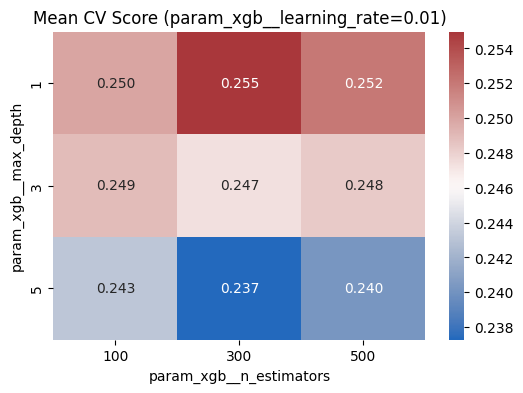

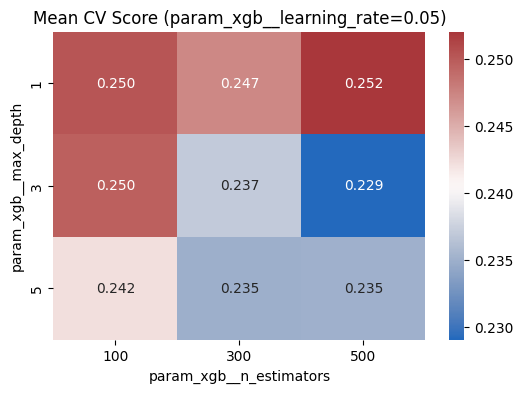

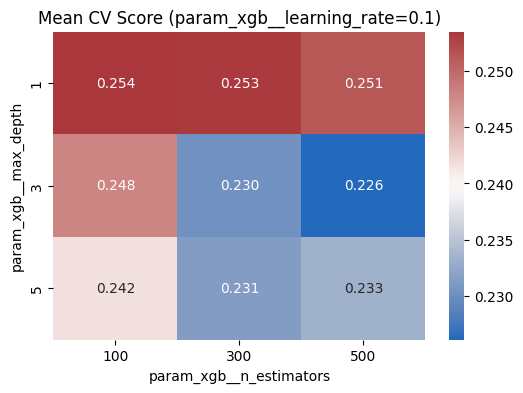

In [23]:
visualise_gridsearch(pd.DataFrame(undersampling_grid.cv_results_),
                     'param_xgb__max_depth', 'param_xgb__n_estimators', 'param_xgb__learning_rate')

In [75]:
best_model = undersampling_grid.best_estimator_

top10_list = make_top_3(best_model, X_test_sets, y_test_sets_class)
hit_list = fetch_top_predictions(top10_list, X_test_sets, y_test_sets_class, y_test_sets_reg_log)

np.average(hit_list)
score_collector['xgb']['undersampling'] = round(np.average(hit_list), 4)
at_least_one_collector['xgb']['undersampling'] = sum([i>=1 for i in hit_list])/100


### **XGBoost with undersampling and SMOTE**

In [25]:
smote_pipeline = ImbPipeline([
    ("resample", SMOTETomek(random_state=42)),
    ("xgb", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

smote_param_grid = {
    "xgb__n_estimators": [100, 300, 500],
    "xgb__learning_rate": [0.01, 0.05, 0.1],
    "xgb__max_depth": [1, 3, 5, 7],
}

smote_grid = GridSearchCV(
    estimator=smote_pipeline,
    param_grid=smote_param_grid,
    scoring=topk_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

print("\n=== Running GridSearchCV ===")
smote_grid.fit(X_train, y_train_class)
print("\nBest parameters:", smote_grid.best_params_)
print("Best CV score:", round(smote_grid.best_score_, 3))
cv_collector['xgb']['smote'] = round(smote_grid.best_score_, 4)


=== Running GridSearchCV ===
Fitting 3 folds for each of 36 candidates, totalling 108 fits



Best parameters: {'xgb__learning_rate': 0.1, 'xgb__max_depth': 3, 'xgb__n_estimators': 300}
Best CV score: 0.249


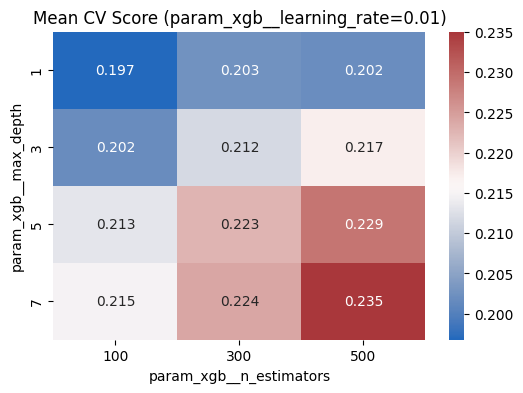

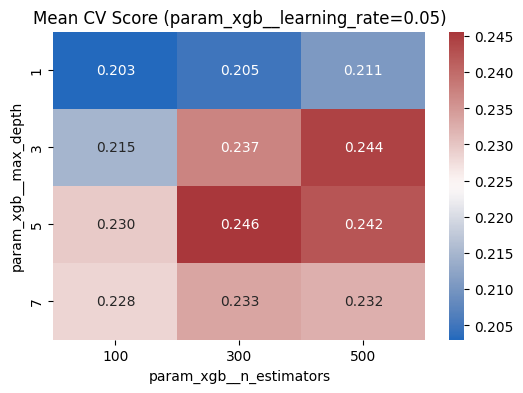

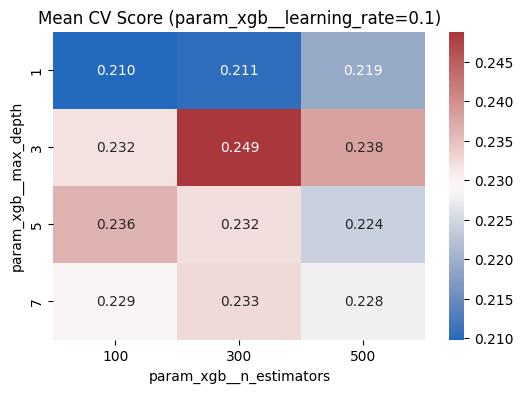

In [26]:
visualise_gridsearch(pd.DataFrame(smote_grid.cv_results_),
                     'param_xgb__max_depth', 'param_xgb__n_estimators', 'param_xgb__learning_rate')

In [76]:
best_model = smote_grid.best_estimator_

top10_list = make_top_3(best_model, X_test_sets, y_test_sets_class)
hit_list = fetch_top_predictions(top10_list, X_test_sets, y_test_sets_class, y_test_sets_reg_log)

np.average(hit_list)
score_collector['xgb']['smote'] = round(np.average(hit_list), 4)
at_least_one_collector['xgb']['smote'] = sum([i>=1 for i in hit_list])/100

### **XGBoost regression**

In [28]:
reg_pipeline = SkPipeline([
    ("xgb", XGBRegressor(
        random_state=42,
    ))
])

reg_param_grid = {
    "xgb__n_estimators": [50, 100, 300, 500],
    "xgb__learning_rate": [0.01, 0.05, 0.1],
    "xgb__max_depth": [1, 3, 5, 7],
}

reg_grid = GridSearchCV(
    estimator=reg_pipeline,
    param_grid=reg_param_grid,
    scoring=topk_regression_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

print("\n=== Running GridSearchCV for XGBRegressor ===")
reg_grid.fit(X_train, y_train_reg_log)
print("\nBest parameters:", reg_grid.best_params_)
print("Best CV score:", round(reg_grid.best_score_, 3))
cv_collector['xgb']['regression'] = round(reg_grid.best_score_, 4)


=== Running GridSearchCV for XGBRegressor ===
Fitting 3 folds for each of 48 candidates, totalling 144 fits



Best parameters: {'xgb__learning_rate': 0.05, 'xgb__max_depth': 7, 'xgb__n_estimators': 300}
Best CV score: 0.243


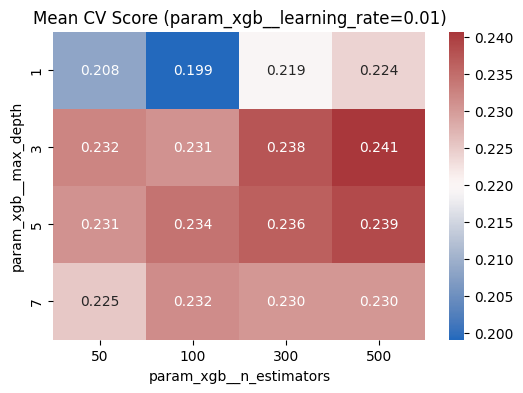

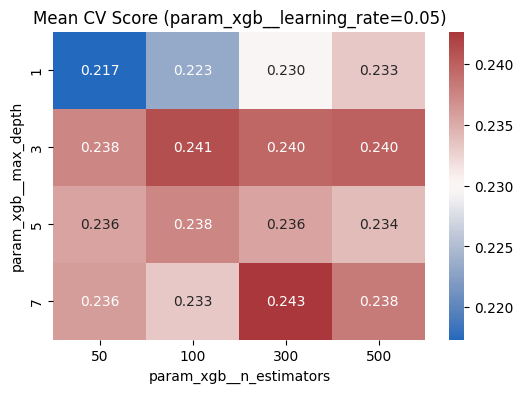

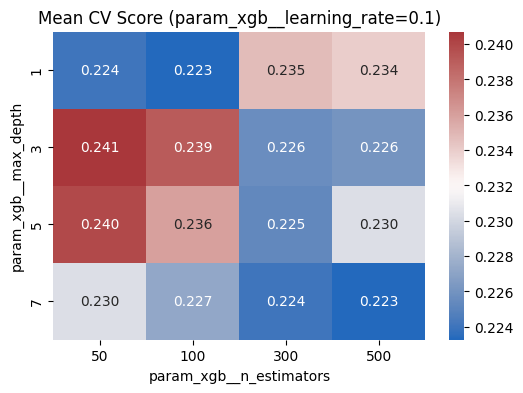

In [29]:
visualise_gridsearch(pd.DataFrame(reg_grid.cv_results_), 
                     'param_xgb__max_depth', 'param_xgb__n_estimators', 'param_xgb__learning_rate')

In [77]:
best_model = reg_grid.best_estimator_

top10_list = make_top_3(best_model, X_test_sets, y_test_sets_class, regression=True)
hit_list = fetch_top_predictions(top10_list, X_test_sets, y_test_sets_class, y_test_sets_reg_log)

np.average(hit_list)
score_collector['xgb']['regression'] = round(np.average(hit_list), 4)
at_least_one_collector['xgb']['regression'] = sum([i>=1 for i in hit_list])/100

### **Random Forest baseline**


In [31]:

randomForest_pipeline = ImbPipeline(steps=[
    ('clf', RandomForestClassifier(200,random_state=42))
])


randomForest_param_grid = {
    'clf__max_depth': [3, 10, 15, 25],
    'clf__min_samples_split': [3, 5, 10, 20],
    'clf__max_features': ['sqrt']
}

randomForest_grid = GridSearchCV(
    estimator=randomForest_pipeline,
    param_grid=randomForest_param_grid,
    scoring=topk_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)


print("\n=== Running GridSearchCV ===")
randomForest_grid.fit(X_train, y_train_class)
print("\nBest parameters:", randomForest_grid.best_params_)
print("Best CV score:", round(randomForest_grid.best_score_, 3))
cv_collector['rf']['baseline'] = round(randomForest_grid.best_score_, 4)


=== Running GridSearchCV ===
Fitting 3 folds for each of 16 candidates, totalling 48 fits


c:\Program Files\Python312\Lib\site-packages\numpy\ma\core.py:2881: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,



Best parameters: {'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_split': 3}
Best CV score: 0.261


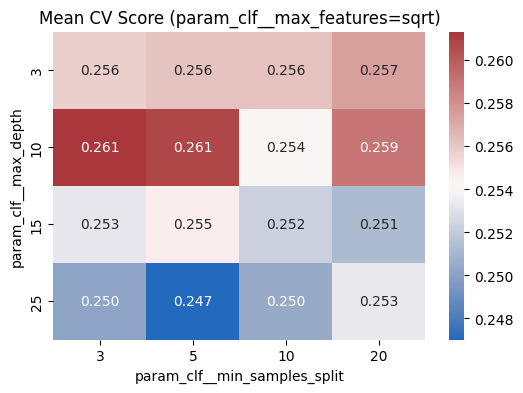

In [32]:
visualise_gridsearch(pd.DataFrame(randomForest_grid.cv_results_), 
                     'param_clf__max_depth', 'param_clf__min_samples_split', 'param_clf__max_features')

In [78]:
best_model = randomForest_grid.best_estimator_

top3_list = make_top_3(best_model, X_test_sets, y_test_sets_class)
hit_list = fetch_top_predictions(top3_list, X_test_sets, y_test_sets_class, y_test_sets_reg_log)

np.average(hit_list)
score_collector['rf']['baseline'] = round(np.average(hit_list), 4)
at_least_one_collector['rf']['baseline'] = sum([i>=1 for i in hit_list])/100

### **Random Forest with undersampling**


In [34]:

randomForest_underSample_pipeline = ImbPipeline(steps=[
    ('undersample', RandomUnderSampler(random_state=42)),
    ('clf', RandomForestClassifier(200,random_state=42))
])


randomForest_underSample_param_grid = {
    'clf__max_depth': [3, 10, 15, 25],
    'clf__min_samples_split': [3, 5, 10, 20],
    'clf__max_features': ['sqrt']
}

randomForest_underSample_grid = GridSearchCV(
    estimator=randomForest_underSample_pipeline,
    param_grid=randomForest_underSample_param_grid,
    scoring=topk_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)


print("\n=== Running GridSearchCV ===")
randomForest_underSample_grid.fit(X_train, y_train_class)
print("\nBest parameters:", randomForest_underSample_grid.best_params_)
print("Best CV score:", round(randomForest_underSample_grid.best_score_, 3))
cv_collector['rf']['undersampling'] = round(randomForest_underSample_grid.best_score_, 4)


=== Running GridSearchCV ===
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Best parameters: {'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_split': 10}
Best CV score: 0.259


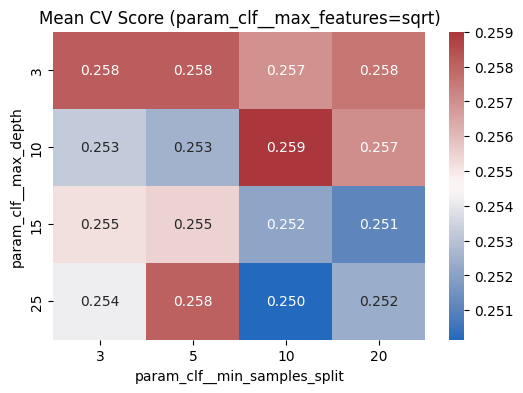

In [35]:
# cv_results_df = pd.DataFrame(standard_grid.cv_results_)
# print(cv_results_df.columns)

visualise_gridsearch(pd.DataFrame(randomForest_underSample_grid.cv_results_), 
                     'param_clf__max_depth', 'param_clf__min_samples_split', 'param_clf__max_features')

In [79]:
best_model = randomForest_underSample_grid.best_estimator_

top3_list = make_top_3(best_model, X_test_sets, y_test_sets_class)
hit_list = fetch_top_predictions(top3_list, X_test_sets, y_test_sets_class, y_test_sets_reg_log)

np.average(hit_list)
score_collector['rf']['undersampling'] = round(np.average(hit_list), 4)
at_least_one_collector['rf']['undersampling'] = sum([i>=1 for i in hit_list])/100

### **Random Forest with undersampling and SMOTE**


In [37]:

randomForest_smote_pipeline = ImbPipeline(steps=[
    ("resample", SMOTETomek(sampling_strategy=0.3, random_state=42)),
    ('clf', RandomForestClassifier(200,random_state=42))
])


randomForest_smote_param_grid = {
    'clf__max_depth': [3, 10, 15, 25],
    'clf__min_samples_split': [3, 5, 10, 20],
    'clf__max_features': ['sqrt']
}

randomForest_smote_grid = GridSearchCV(
    estimator=randomForest_smote_pipeline,
    param_grid=randomForest_smote_param_grid,
    scoring=topk_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)


print("\n=== Running GridSearchCV ===")
randomForest_smote_grid.fit(X_train, y_train_class)
print("\nBest parameters:", randomForest_smote_grid.best_params_)
print("Best CV score:", round(randomForest_smote_grid.best_score_, 3))
cv_collector['rf']['smote'] = round(randomForest_smote_grid.best_score_, 4)


=== Running GridSearchCV ===
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Best parameters: {'clf__max_depth': 15, 'clf__max_features': 'sqrt', 'clf__min_samples_split': 3}
Best CV score: 0.257


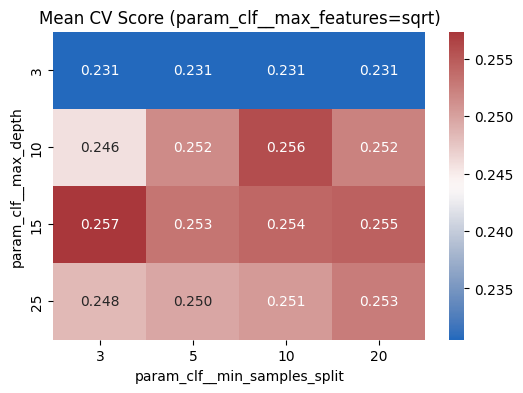

In [38]:
visualise_gridsearch(pd.DataFrame(randomForest_smote_grid.cv_results_), 
                     'param_clf__max_depth', 'param_clf__min_samples_split', 'param_clf__max_features')

In [80]:
best_model = randomForest_smote_grid.best_estimator_

top3_list = make_top_3(best_model, X_test_sets, y_test_sets_class)
hit_list = fetch_top_predictions(top3_list, X_test_sets, y_test_sets_class, y_test_sets_reg_log)

np.average(hit_list)
score_collector['rf']['smote'] = round(np.average(hit_list), 4)
at_least_one_collector['rf']['smote'] = sum([i>=1 for i in hit_list])/100

### **Random Forest regression**

In [40]:
randomForest_regressor_pipeline = ImbPipeline(steps=[
    ('clf', RandomForestRegressor(200,random_state=42))
])


randomForest_regressor_param_grid = {
    'clf__max_depth': [3, 10, 15, 25],
    'clf__min_samples_split': [3, 5, 10, 20],
    'clf__max_features': ['sqrt']
}

randomForest_regressor_grid = GridSearchCV(
    estimator=randomForest_regressor_pipeline,
    param_grid=randomForest_regressor_param_grid,
    scoring=topk_regression_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)


print("\n=== Running GridSearchCV ===")
randomForest_regressor_grid.fit(X_train, y_train_class)
print("\nBest parameters:", randomForest_regressor_grid.best_params_)
print("Best CV score:", round(randomForest_regressor_grid.best_score_, 3))
cv_collector['rf']['regression'] = round(randomForest_regressor_grid.best_score_, 4)


=== Running GridSearchCV ===
Fitting 3 folds for each of 16 candidates, totalling 48 fits


c:\Program Files\Python312\Lib\site-packages\numpy\ma\core.py:2881: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,



Best parameters: {'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_split': 3}
Best CV score: 0.245


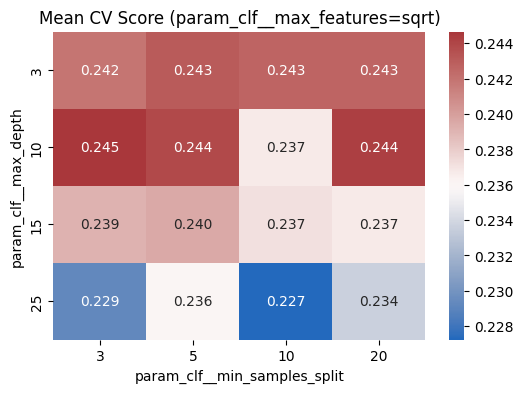

In [41]:
visualise_gridsearch(pd.DataFrame(randomForest_regressor_grid.cv_results_), 
                     'param_clf__max_depth', 'param_clf__min_samples_split', 'param_clf__max_features')

In [81]:
best_model = randomForest_regressor_grid.best_estimator_

top3_list = make_top_3(best_model, X_test_sets, y_test_sets_class, regression=True)
hit_list = fetch_top_predictions(top3_list, X_test_sets, y_test_sets_class, y_test_sets_reg_log)

np.average(hit_list)
score_collector['rf']['regression'] = round(np.average(hit_list), 4)
at_least_one_collector['rf']['regression'] = sum([i>=1 for i in hit_list])/100


### **Catboost baseline**

In [43]:
cat_pipeline = SkPipeline([
    ("cat", CatBoostClassifier(
        random_state=42,
        verbose=False,
        grow_policy = "SymmetricTree"
    ))
])

cat_param_grid = {
    "cat__iterations": [200, 400, 600],
    "cat__learning_rate": [0.01, 0.05, 0.1],
    "cat__depth": [4, 6, 8],
}

cat_grid = GridSearchCV(
    estimator=cat_pipeline,
    param_grid=cat_param_grid,
    scoring=topk_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)


print("\n=== Running GridSearchCV ===")
cat_grid.fit(X_train, y_train_class)
print("\nBest parameters:", cat_grid.best_params_)
print("Best CV score:", round(cat_grid.best_score_, 3))
cv_collector['cat']['baseline'] = round(cat_grid.best_score_, 4)


=== Running GridSearchCV ===
Fitting 3 folds for each of 27 candidates, totalling 81 fits

Best parameters: {'cat__depth': 6, 'cat__iterations': 200, 'cat__learning_rate': 0.05}
Best CV score: 0.268


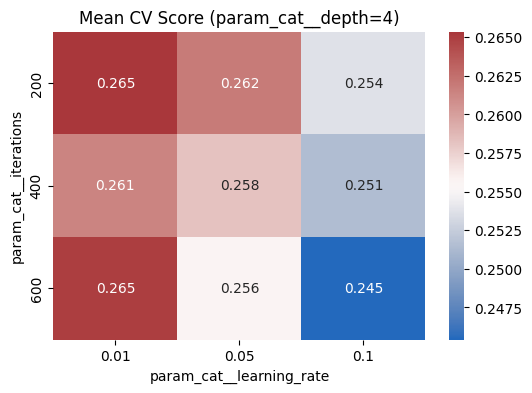

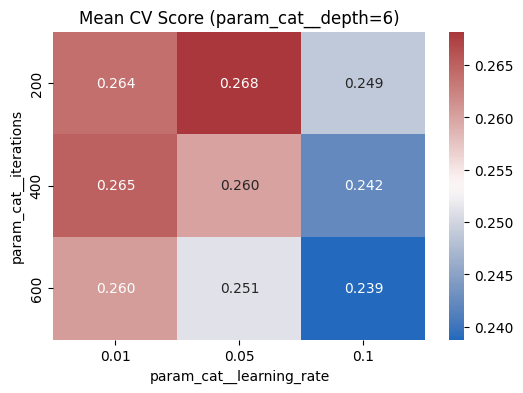

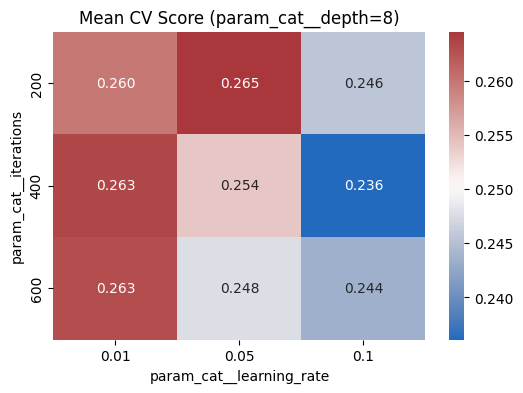

In [44]:
visualise_gridsearch(pd.DataFrame(cat_grid.cv_results_), 
                     'param_cat__iterations', 'param_cat__learning_rate', 'param_cat__depth')

In [82]:
best_model = cat_grid.best_estimator_

top10_list = make_top_3(best_model, X_test_sets, y_test_sets_class)
hit_list = fetch_top_predictions(top10_list, X_test_sets, y_test_sets_class, y_test_sets_reg_log)

print(np.average(hit_list))
score_collector['cat']['baseline'] = round(np.average(hit_list), 4)
at_least_one_collector['cat']['baseline'] = sum([i>=1 for i in hit_list])/100

0.75


### **Catboost with undersampling**

In [46]:
cat_undersampling_pipeline = ImbPipeline([
    ('undersample', RandomUnderSampler(random_state=42)),
    ('cat', CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="Logloss",
        random_state=42,
        verbose=False,
        grow_policy = "SymmetricTree"
    ))
])

cat_undersampling_param_grid = {
    "cat__iterations": [100, 300, 500],
    "cat__learning_rate": [0.01, 0.05, 0.1],
    "cat__depth": [1, 3, 5],
}

cat_undersampling_grid = GridSearchCV(
    estimator=cat_undersampling_pipeline,
    param_grid=cat_undersampling_param_grid,
    scoring=topk_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

print("\n=== Running GridSearchCV ===")
cat_undersampling_grid.fit(X_train, y_train_class)
print("\nBest parameters:", cat_undersampling_grid.best_params_)
print("Best CV score:", round(cat_undersampling_grid.best_score_, 3))
cv_collector['cat']['undersampling'] = round(cat_undersampling_grid.best_score_, 4)


=== Running GridSearchCV ===
Fitting 3 folds for each of 27 candidates, totalling 81 fits

Best parameters: {'cat__depth': 3, 'cat__iterations': 100, 'cat__learning_rate': 0.05}
Best CV score: 0.264


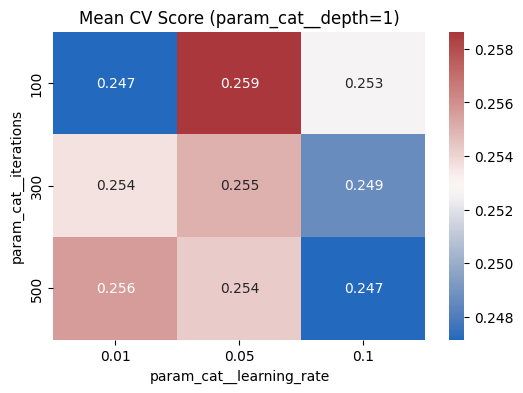

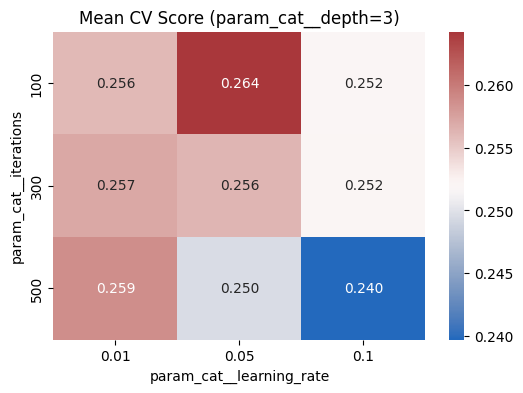

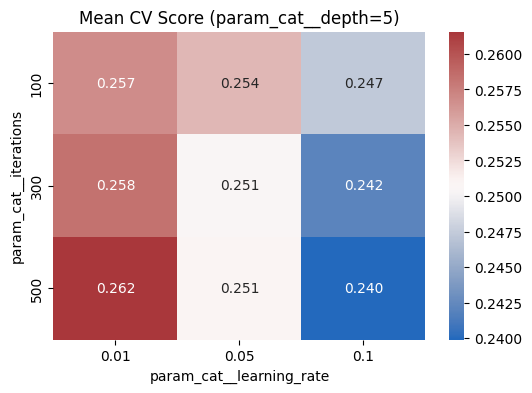

In [47]:
visualise_gridsearch(pd.DataFrame(cat_undersampling_grid.cv_results_), 
                     'param_cat__iterations', 'param_cat__learning_rate', 'param_cat__depth')

In [83]:
best_model = cat_undersampling_grid.best_estimator_

top10_list = make_top_3(best_model, X_test_sets, y_test_sets_class)
hit_list = fetch_top_predictions(top10_list, X_test_sets, y_test_sets_class, y_test_sets_reg_log)

print(np.average(hit_list))
score_collector['cat']['undersampling'] = round(np.average(hit_list), 4)
at_least_one_collector['cat']['undersampling'] = sum([i>=1 for i in hit_list])/100

0.81


### **Catboost with undersampling and SMOTE**

In [49]:
cat_smote_pipeline = ImbPipeline([
    ("resample", SMOTETomek(random_state=42)),
    ("cat", CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="Logloss",
        random_state=42,
        verbose=False,
        grow_policy = "SymmetricTree"
    ))
])

cat_smote_param_grid = {
    "cat__iterations": [100, 300, 500],
    "cat__learning_rate": [0.01, 0.05, 0.1],
    "cat__depth": [1, 3, 5, 7],
}

cat_smote_grid = GridSearchCV(
    estimator=cat_smote_pipeline,
    param_grid=cat_smote_param_grid,
    scoring=topk_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

print("\n=== Running GridSearchCV ===")
cat_smote_grid.fit(X_train, y_train_class)
print("\nBest parameters:", cat_smote_grid.best_params_)
print("Best CV score:", round(cat_smote_grid.best_score_, 3))
cv_collector['cat']['smote'] = round(cat_smote_grid.best_score_, 4)


=== Running GridSearchCV ===
Fitting 3 folds for each of 36 candidates, totalling 108 fits


c:\Program Files\Python312\Lib\site-packages\numpy\ma\core.py:2881: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,



Best parameters: {'cat__depth': 7, 'cat__iterations': 500, 'cat__learning_rate': 0.05}
Best CV score: 0.256


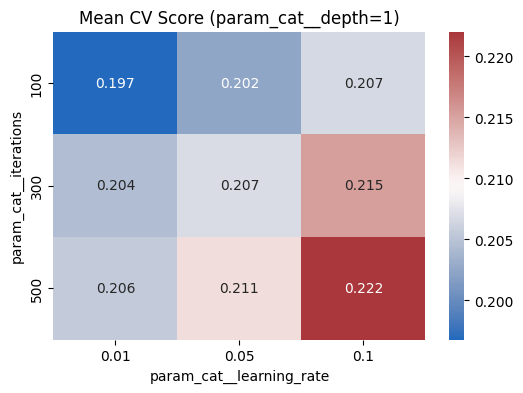

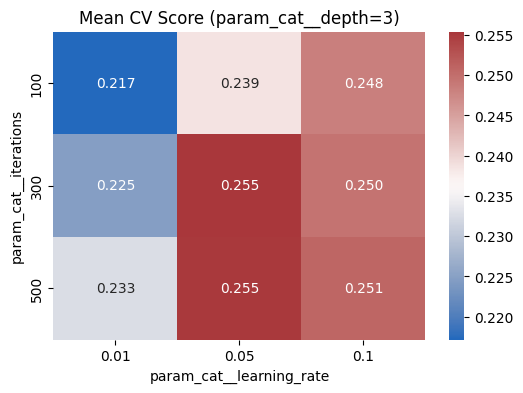

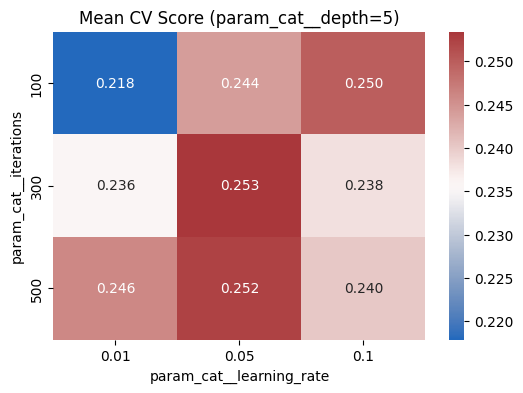

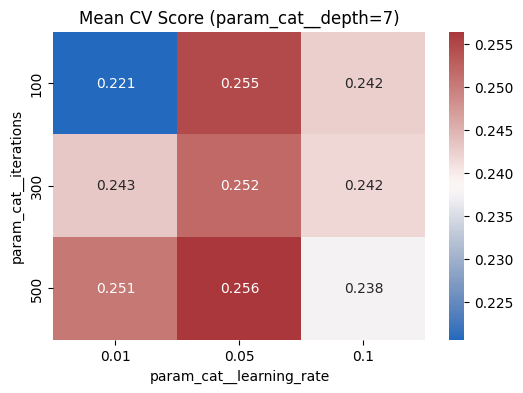

In [50]:
visualise_gridsearch(pd.DataFrame(cat_smote_grid.cv_results_), 
                     'param_cat__iterations', 'param_cat__learning_rate', 'param_cat__depth')

In [84]:
best_model = cat_smote_grid.best_estimator_

top10_list = make_top_3(best_model, X_test_sets, y_test_sets_class)
hit_list = fetch_top_predictions(top10_list, X_test_sets, y_test_sets_class, y_test_sets_reg_log)

print(np.average(hit_list))
score_collector['cat']['smote'] = round(np.average(hit_list), 4)
at_least_one_collector['cat']['smote'] = sum([i>=1 for i in hit_list])/100

0.79


### **Catboost regression**

In [52]:
cat_reg_pipeline = SkPipeline([
    ("cat", CatBoostRegressor(
        loss_function="RMSE",
        random_state=42,
        verbose=False,
        grow_policy="SymmetricTree"
    ))
])

cat_reg_param_grid = {
    "cat__iterations": [50, 100, 300, 500],
    "cat__learning_rate": [0.01, 0.05, 0.1],
    "cat__depth": [1, 3, 5, 7],
}

cat_reg_grid = GridSearchCV(
    estimator=cat_reg_pipeline,
    param_grid=cat_reg_param_grid,
    scoring=topk_regression_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

print("\n=== Running GridSearchCV ===")
cat_reg_grid.fit(X_train, y_train_class)
print("\nBest parameters:", cat_reg_grid.best_params_)
print("Best CV score:", round(cat_reg_grid.best_score_, 3))
cv_collector['cat']['regression'] = round(cat_reg_grid.best_score_, 4)


=== Running GridSearchCV ===
Fitting 3 folds for each of 48 candidates, totalling 144 fits

Best parameters: {'cat__depth': 1, 'cat__iterations': 300, 'cat__learning_rate': 0.1}
Best CV score: 0.251


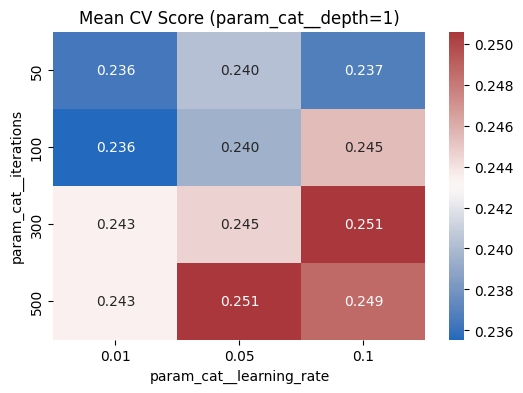

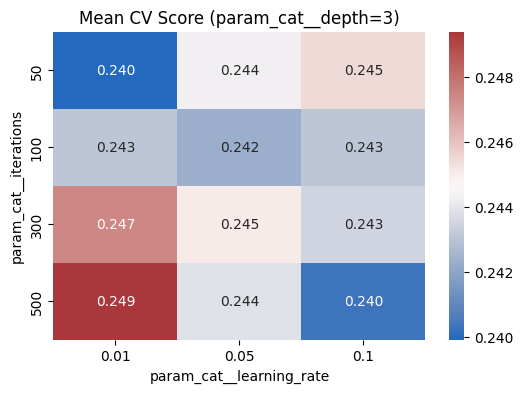

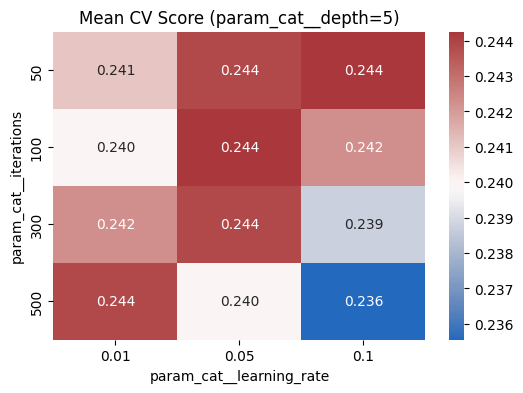

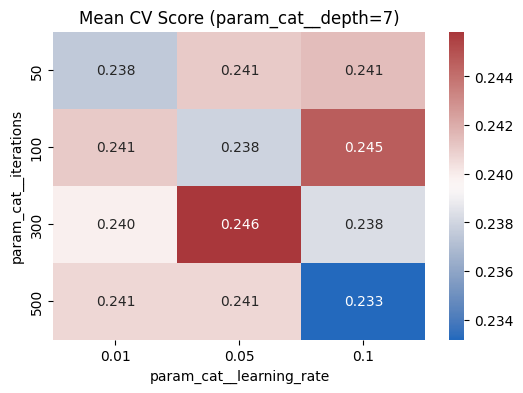

In [53]:
visualise_gridsearch(pd.DataFrame(cat_reg_grid.cv_results_), 
                     'param_cat__iterations', 'param_cat__learning_rate', 'param_cat__depth')

In [85]:
best_model = cat_reg_grid.best_estimator_

top3_list = make_top_3(best_model, X_test_sets, y_test_sets_class, regression=True)
hit_list = fetch_top_predictions(top3_list, X_test_sets, y_test_sets_class, y_test_sets_reg_log)

np.average(hit_list)
score_collector['cat']['regression'] = round(np.average(hit_list), 4)
at_least_one_collector['cat']['regression'] = sum([i>=1 for i in hit_list])/100


### **Model comparison**

This section contains the results of the pipeline and a few visuals used in report to convey the main differences.

In [86]:
at_least_one_collector

{'xgb': {'baseline': 0,
  'undersampling': np.float64(0.57),
  'smote': np.float64(0.57),
  'regression': np.float64(0.56)},
 'rf': {'baseline': np.float64(0.58),
  'undersampling': np.float64(0.58),
  'smote': np.float64(0.56),
  'regression': np.float64(0.56)},
 'cat': {'baseline': np.float64(0.62),
  'undersampling': np.float64(0.59),
  'smote': np.float64(0.57),
  'regression': np.float64(0.61)}}

In [56]:
factor = 1 / 3

scores = {
    model: {
        strategy: round(float(value) * factor, 4)
        for strategy, value in scores.items()
    }
    for model, scores in score_collector.items()
}

scores

{'xgb': {'baseline': 0.28,
  'undersampling': 0.25,
  'smote': 0.2633,
  'regression': 0.2333},
 'rf': {'baseline': 0.2433,
  'undersampling': 0.2333,
  'smote': 0.2333,
  'regression': 0.23},
 'cat': {'baseline': 0.25,
  'undersampling': 0.27,
  'smote': 0.2633,
  'regression': 0.26}}

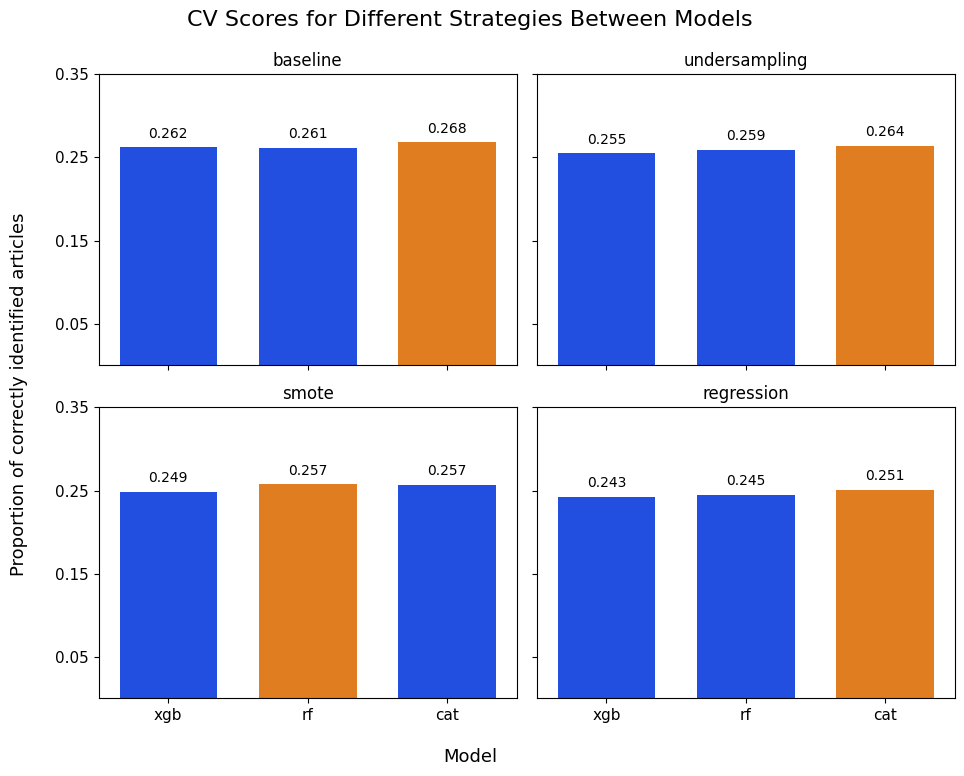

In [57]:
df = pd.DataFrame(cv_collector).T.reset_index().melt(
    id_vars='index', var_name='Strategy', value_name='Score')
df.rename(columns={'index': 'Model'}, inplace=True)

strategies = df['Strategy'].unique()
models = df['Model'].unique()
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()

bright_palette = sns.color_palette('bright')
blue = bright_palette[0]
orange = bright_palette[1]

for i, strategy in enumerate(strategies):
    ax = axes[i]
    subset = df[df['Strategy'] == strategy]
    ax.set_title(strategy, fontsize=12)

    colors = [orange if score == subset['Score'].max() else blue for score in subset['Score']]

    sns.barplot(
        x='Model',
        y='Score',
        data=subset,
        ax=ax,
        palette=colors,
        width=0.7
    )

    for p in ax.patches:
        height = p.get_height()
        ax.text(
            p.get_x() + p.get_width() / 2,
            height + 0.008,
            f"{height:.3f}",
            ha='center',
            va='bottom',
            fontsize=10
        )

    yticks = np.arange(0.05, 0.36, 0.1)
    ax.set_yticks(yticks)
    ax.set_yticklabels([f"{x:.2f}" for x in yticks])
    ax.set_ylim(0, 0.35)

    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelsize=11)
    ax.tick_params(axis='y', labelsize=11)


fig.suptitle("CV Scores for Different Strategies Between Models", fontsize=16)

fig.text(0.04, 0.5, 'Proportion of correctly identified articles', va='center', rotation='vertical', fontsize=13)
fig.text(0.5, 0.04, 'Model', ha='center', rotation='horizontal', fontsize=13)

plt.tight_layout(rect=[0.07, 0.07, 1, 0.99])
plt.show()

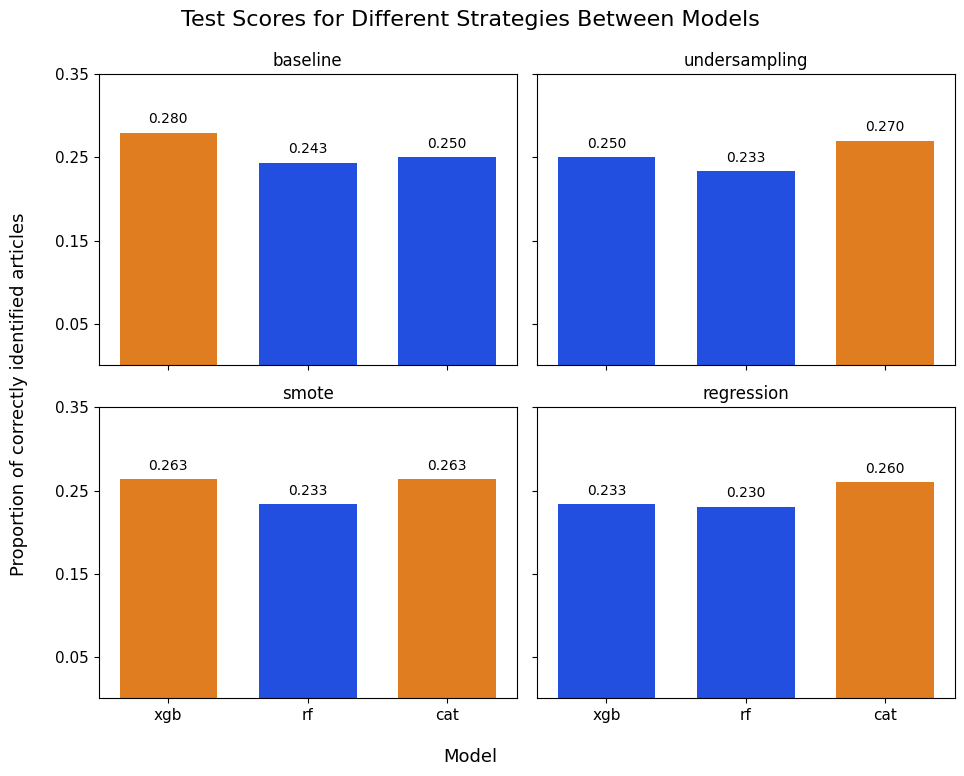

In [58]:
df = pd.DataFrame(scores).T.reset_index().melt(
    id_vars='index', var_name='Strategy', value_name='Score')
df.rename(columns={'index': 'Model'}, inplace=True)

strategies = df['Strategy'].unique()
models = df['Model'].unique()
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()

bright_palette = sns.color_palette('bright')
blue = bright_palette[0]
orange = bright_palette[1]

for i, strategy in enumerate(strategies):
    ax = axes[i]
    subset = df[df['Strategy'] == strategy]
    ax.set_title(strategy, fontsize=12)

    colors = [orange if score == subset['Score'].max() else blue for score in subset['Score']]

    sns.barplot(
        x='Model',
        y='Score',
        data=subset,
        ax=ax,
        palette=colors,
        width=0.7
    )

    for p in ax.patches:
        height = p.get_height()
        ax.text(
            p.get_x() + p.get_width() / 2,
            height + 0.008,
            f"{height:.3f}",
            ha='center',
            va='bottom',
            fontsize=10
        )

    yticks = np.arange(0.05, 0.36, 0.1)
    ax.set_yticks(yticks)
    ax.set_yticklabels([f"{x:.2f}" for x in yticks])
    ax.set_ylim(0, 0.35)

    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelsize=11)
    ax.tick_params(axis='y', labelsize=11)

fig.suptitle("Test Scores for Different Strategies Between Models", fontsize=16)

fig.text(0.04, 0.5, 'Proportion of correctly identified articles', va='center', rotation='vertical', fontsize=13)
fig.text(0.5, 0.04, 'Model', ha='center', rotation='horizontal', fontsize=13)

plt.tight_layout(rect=[0.07, 0.07, 1, 0.99])
plt.show()

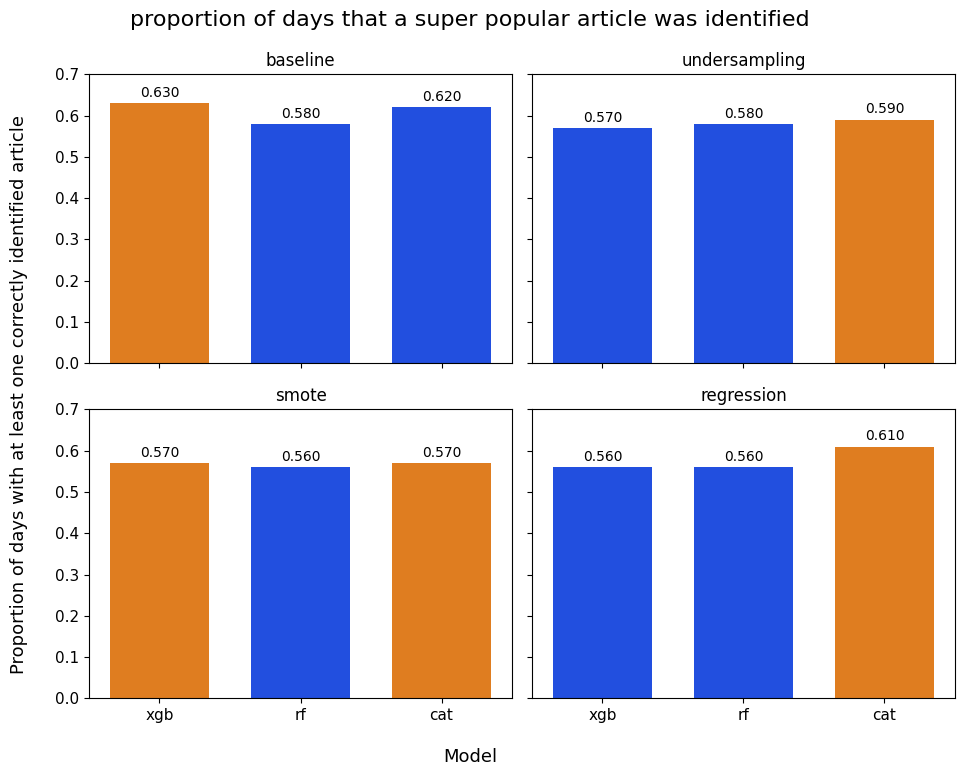

In [93]:
df = pd.DataFrame(at_least_one_collector).T.reset_index().melt(
    id_vars='index', var_name='Strategy', value_name='Score')
df.rename(columns={'index': 'Model'}, inplace=True)

strategies = df['Strategy'].unique()
models = df['Model'].unique()
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()

bright_palette = sns.color_palette('bright')
blue = bright_palette[0]
orange = bright_palette[1]

for i, strategy in enumerate(strategies):
    ax = axes[i]
    subset = df[df['Strategy'] == strategy]
    ax.set_title(strategy, fontsize=12)

    colors = [orange if score == subset['Score'].max() else blue for score in subset['Score']]

    sns.barplot(
        x='Model',
        y='Score',
        data=subset,
        ax=ax,
        palette=colors,
        width=0.7
    )

    for p in ax.patches:
        height = p.get_height()
        ax.text(
            p.get_x() + p.get_width() / 2,
            height + 0.008,
            f"{height:.3f}",
            ha='center',
            va='bottom',
            fontsize=10
        )

    # yticks = np.arange(0.05, 0.36, 0.1)
    # ax.set_yticks(yticks)
    # ax.set_yticklabels([f"{x:.2f}" for x in yticks])
    ax.set_ylim(0, 0.7)

    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelsize=11)
    ax.tick_params(axis='y', labelsize=11)


fig.suptitle("proportion of days that a super popular article was identified", fontsize=16)

fig.text(0.04, 0.5, 'Proportion of days with at least one correctly identified article', va='center', rotation='vertical', fontsize=13)
fig.text(0.5, 0.04, 'Model', ha='center', rotation='horizontal', fontsize=13)

plt.tight_layout(rect=[0.07, 0.07, 1, 0.99])
plt.show()

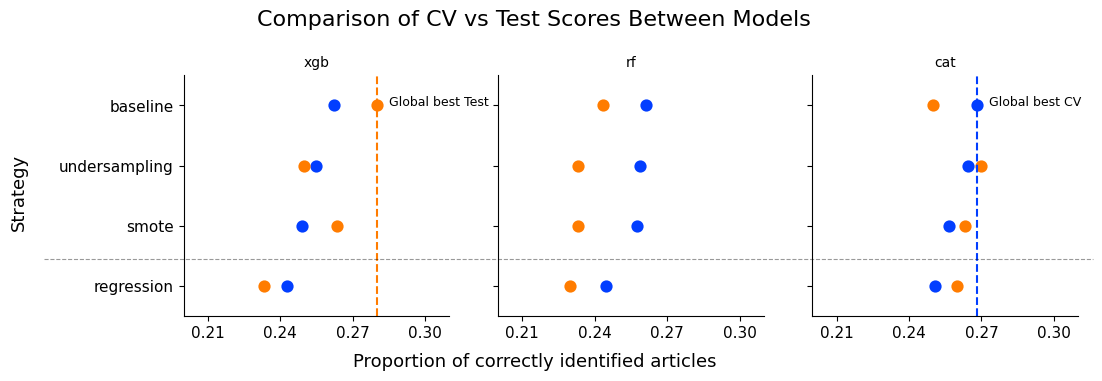

In [59]:
def scores_dict_to_df(scores, split_name):
    return (
        pd.DataFrame(scores)
        .T
        .reset_index()
        .melt(id_vars='index', var_name='Strategy', value_name='Score')
        .assign(Split=split_name)
        .rename(columns={'index': 'Model'})
    )


df_cv = scores_dict_to_df(cv_collector, 'CV')
df_test = scores_dict_to_df(scores, 'Test')

df = pd.concat([df_cv, df_test], ignore_index=True)

g = sns.catplot(
    data=df,
    y='Strategy',
    x='Score',
    hue='Split',
    col='Model',
    kind='point',
    dodge=False,
    linestyle='none',
    height=3.8,
    aspect=1.0,
    legend=False,
    sharey=True,
    sharex=True,
    palette=bright_palette[:2]
)

best_cv = df[df['Split'] == 'CV']['Score'].max()
best_test = df[df['Split'] == 'Test']['Score'].max()

g.axes.flatten()[0].axvline(best_test, color=orange, linestyle='--', label='Best Test')
g.axes.flatten()[-1].axvline(best_cv, color=blue, linestyle='--', label='Best CV')

g.axes.flatten()[0].text(best_test + 0.005, 0, 'Global best Test', color='black', ha='left', fontsize=9)
g.axes.flatten()[-1].text(best_cv + 0.005, 0, 'Global best CV', color='black', ha='left', fontsize=9)

for ax in g.axes.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=11)
    ax.tick_params(axis='y', labelsize=11)


ax0 = g.axes.flatten()[0]
y_fig = ax0.transData.transform((0, 2.6))[1]
y_fig = g.figure.transFigure.inverted().transform((0, y_fig))[1]

line = Line2D(
    [0.07, 0.99],
    [y_fig, y_fig],
    transform=g.figure.transFigure,
    color='black',
    linewidth=0.8,
    alpha=0.4,
    linestyle='--'
)

g.figure.add_artist(line)

g.set(xlim=(0.2, 0.31))
g.set(xticks=[0.21, 0.24, 0.27, 0.3], xticklabels=['0.21', '0.24', '0.27', '0.30'])

g.figure.suptitle("Comparison of CV vs Test Scores Between Models", fontsize=16)
g.set_titles('{col_name}', fontsize=12)
g.figure.text(0.04, 0.5, 'Strategy', va='center', rotation='vertical', fontsize=13)
g.figure.text(0.5, 0.04, 'Proportion of correctly identified articles', ha='center', rotation='horizontal', fontsize=13)

g.tight_layout(rect=[0.07, 0.07, 0.99, 0.99])
plt.show()